In [1]:
import pandas as pd
import matplotlib as mpl
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('lrm.xlsx')
data

,Restaurant,Student_Population,Sales
0,1,2,58
1,2,6,105
2,3,8,88
3,4,8,118
4,5,12,117
5,6,16,137
6,7,20,157
7,8,20,169
8,9,22,149
9,10,26,202


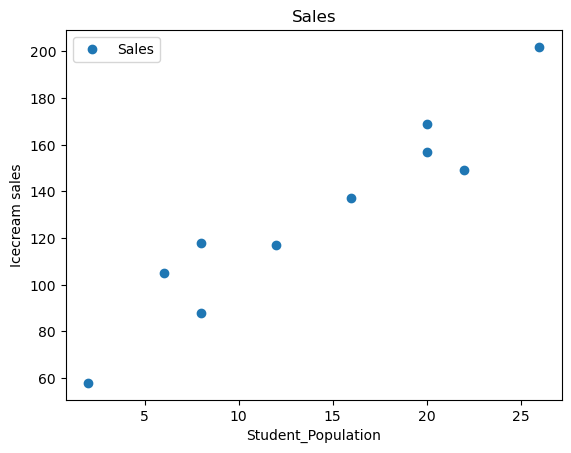

In [3]:
data.plot('Student_Population', 'Sales', style='o')
plt.ylabel('Icecream sales')
plt.title('Sales')
plt.show()

In [4]:
import statsmodels.api as s
st_pop = data['Student_Population']
sales = data['Sales']
st_pop = s.add_constant(st_pop)
model1 = s.OLS(sales, st_pop)
result1 = model1.fit()
print(result1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     74.25
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.55e-05
Time:                        15:45:50   Log-Likelihood:                -39.342
No. Observations:                  10   AIC:                             82.68
Df Residuals:                       8   BIC:                             83.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 60.0000      9

In [5]:
x = data['Student_Population'].values.reshape(-1, 1)
y = data['Sales'].values.reshape(-1, 1)

In [6]:
reg = LinearRegression()
reg.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print(reg.intercept_[0], reg.coef_[0][0])

60.0 5.0


In [8]:
reg.predict([[10]])

array([[110.]])

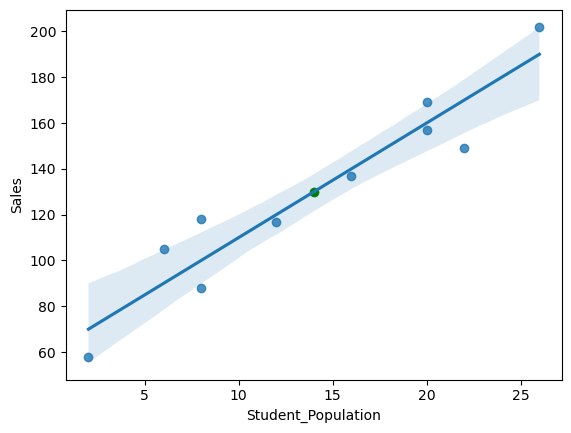

In [9]:
x = data['Student_Population']
y = data['Sales']
plt.figure()
sns.regplot(x=x, y=y, fit_reg=True)
plt.scatter(np.mean(x), np.mean(y), color='green')
plt.show()

In [16]:
from statsmodels.stats.outliers_influence import summary_table

st, data1, ss2 = summary_table(result1, alpha=0.05)
fittedvalues = data1[:, 2]
predict_mean_se = data1[:, 3]
predict_mean_ci_low, predict_mean_ci_upp = data1[:, 4:6].T
predict_ci_low, predict_ci_upp = data1[:, 6:8].T

In [17]:
predict_mean_ci_low

array([ 51.03868339,  75.2931351 ,  87.10977126,  87.10977126,
       109.56629807, 129.56629807, 147.10977126, 147.10977126,
       155.2931351 , 171.03868339])

In [18]:
predict_mean_ci_upp

array([ 88.96131661, 104.7068649 , 112.89022874, 112.89022874,
       130.43370193, 150.43370193, 172.89022874, 172.89022874,
       184.7068649 , 208.96131661])

In [19]:
predict_ci_low

array([ 32.89834155,  54.8817226 ,  65.60291394,  65.60291394,
        86.446108  , 106.446108  , 125.60291394, 125.60291394,
       134.8817226 , 152.89834155])

In [20]:
predict_ci_upp

array([107.10165845, 125.1182774 , 134.39708606, 134.39708606,
       153.553892  , 173.553892  , 194.39708606, 194.39708606,
       205.1182774 , 227.10165845])

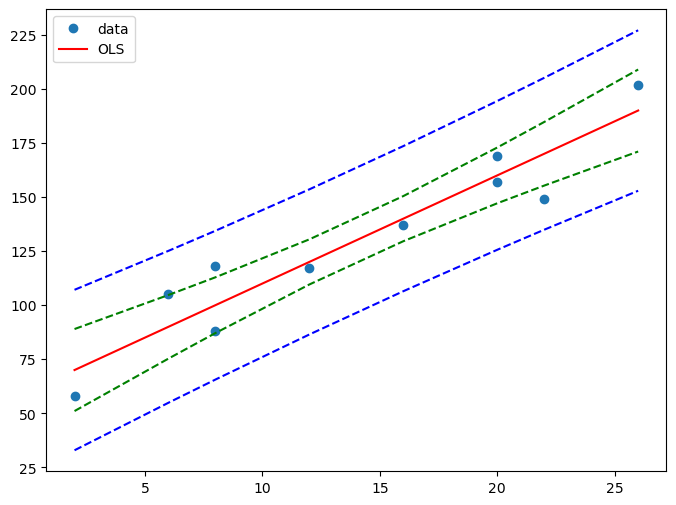

In [21]:
X = s.add_constant(x)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, y, 'o', label='data')
ax.plot(x, fittedvalues, 'r-', label='OLS')
ax.plot(x, predict_ci_low, 'b--')
ax.plot(x, predict_ci_upp, 'b--')
ax.plot(x, predict_mean_ci_low, 'g--')
ax.plot(x, predict_mean_ci_upp, 'g--')
ax.legend(loc='best')
plt.show()

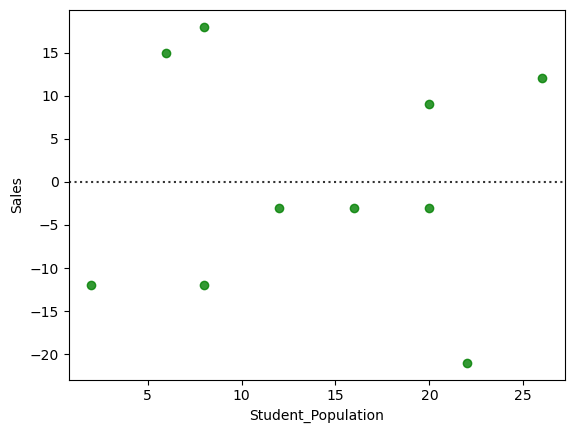

In [27]:
# Residual Plot Against x
sns.residplot(
    x=data['Student_Population'],
    y=data['Sales'],
    color='g'
)
plt.show()